In [8]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [9]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [10]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))


In [11]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [12]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] loss=99.510368  ||x_k-x*||^2=186.200623
[20] loss=0.005304  ||x_k-x*||^2=0.070788
[40] loss=0.000001  ||x_k-x*||^2=0.000012
[60] loss=0.000000  ||x_k-x*||^2=0.000000
[80] loss=0.000000  ||x_k-x*||^2=0.000000
[100] loss=0.000000  ||x_k-x*||^2=0.000000
[120] loss=0.000000  ||x_k-x*||^2=0.000000
[140] loss=0.000000  ||x_k-x*||^2=0.000000
[160] loss=0.000000  ||x_k-x*||^2=0.000000
[180] loss=0.000000  ||x_k-x*||^2=0.000000
[200] loss=0.000000  ||x_k-x*||^2=0.000000
[220] loss=0.000000  ||x_k-x*||^2=0.000000
[240] loss=0.000000  ||x_k-x*||^2=0.000000
[260] loss=0.000000  ||x_k-x*||^2=0.000000
[280] loss=0.000000  ||x_k-x*||^2=0.000000
initial loss: 99.51036834716797
final loss: 2.4173627544143983e-09
Total time: 2.7152 sec
Avg per iteration: 0.009051 sec


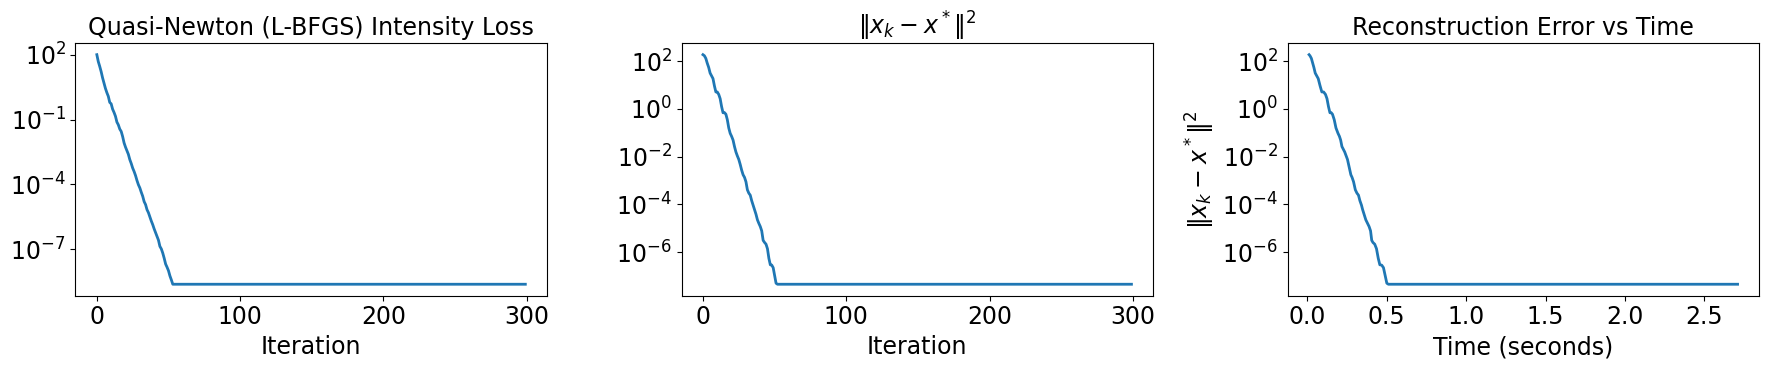

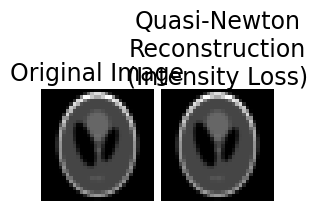

Quasi-Newton Final Loss:         0.000000
Quasi-Newton Final ||x_k-x*||^2: 0.000000


In [13]:
x_phase_qn = physics.A_dagger(y, n_iter=300).clone().detach()
x_phase_qn.requires_grad_(True)

x_true = x_phase.clone().detach()

num_iter = 300
loss_hist = []
recon_error_hist = []
time_hist = []

optimizer = torch.optim.LBFGS(
    [x_phase_qn],
    lr=1.0,
    max_iter=1,            
    history_size=10,
    line_search_fn="strong_wolfe" # None option
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

for i in range(num_iter):
    iter_start = time.perf_counter()

    def closure():
        optimizer.zero_grad()
        loss = intensity_loss(x_phase_qn, y, physics)
        loss.backward()
        return loss

    loss = optimizer.step(closure)

    with torch.no_grad():
        x_corrected = correct_global_phase(x_phase_qn.clone(), x_true)
        recon_error = torch.sum(torch.abs(x_corrected - x_true) ** 2).item()
        recon_error_hist.append(recon_error)
        loss_hist.append(loss.item())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    iter_end = time.perf_counter()
    time_hist.append(iter_end - iter_start)

    if i % 20 == 0:
        print(f"[{i}] loss={loss_hist[-1]:.6f}  ||x_k-x*||^2={recon_error_hist[-1]:.6f}")

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

total_time = end_time - start_time
avg_time = total_time / num_iter

print("initial loss:", loss_hist[0])
print("final loss:", loss_hist[-1])
print(f"Total time: {total_time:.4f} sec")
print(f"Avg per iteration: {avg_time:.6f} sec")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_hist)
axes[0].set_yscale("log")
axes[0].set_title("Quasi-Newton (L-BFGS) Intensity Loss")
axes[0].set_xlabel("Iteration")

axes[1].plot(recon_error_hist)
axes[1].set_yscale("log")
axes[1].set_title(r"$\|x_k - x^*\|^2$")
axes[1].set_xlabel("Iteration")

cumulative_time = np.cumsum(time_hist)
axes[2].plot(cumulative_time, recon_error_hist)
axes[2].set_yscale("log")
axes[2].set_title("Reconstruction Error vs Time")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel(r"$\|x_k - x^*\|^2$")

plt.tight_layout()
plt.show()

x_qn_corrected = correct_global_phase(x_phase_qn.detach(), x_true)
x_qn_recon = torch.angle(x_qn_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot(
    [x_true_vis, x_qn_recon],
    titles=["Original Image", "Quasi-Newton Reconstruction (Intensity Loss)"],
    rescale_mode="clip"
)

final_recon_error = torch.sum(torch.abs(x_qn_corrected - x_true) ** 2).item()
print(f"Quasi-Newton Final Loss:         {loss_hist[-1]:.6f}")
print(f"Quasi-Newton Final ||x_k-x*||^2: {final_recon_error:.6f}")

GD semi-log convergence estimate
Fit range         : [4, 54]
slope             : -4.369440e-01
rho = exp(slope)  : 0.646008
C                 : 6.004406e+02
R^2               : 0.998928
ratio mean        : 0.670441
ratio median      : 0.654445
ratio std         : 0.153499
model             : e_k ≈ C * rho^k


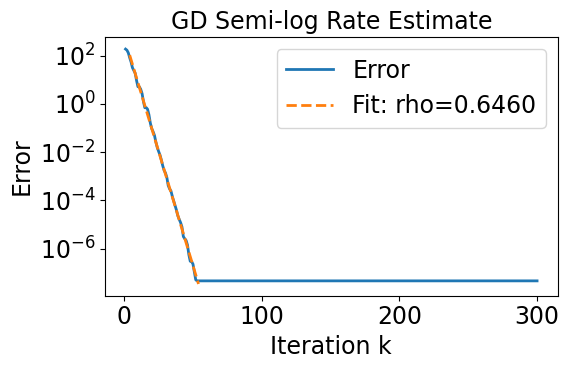

In [18]:
result_qn = {
    "x_final": x_phase_qn.detach(),
    "loss_hist": loss_hist,
    "recon_error_hist": recon_error_hist,
    "time_hist": time_hist,
    "total_time": total_time,
    "avg_time": avg_time,
}

gd_rate = estimate_semilog_rate(
    error_hist=result_qn["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.18,
    method_name="GD",
    plot=True
)

[0] loss=40.129734  ||x_k-x*||^2=175.799530
[20] loss=0.000004  ||x_k-x*||^2=0.000019
[40] loss=0.000000  ||x_k-x*||^2=0.000000
[60] loss=0.000000  ||x_k-x*||^2=0.000000
[80] loss=0.000000  ||x_k-x*||^2=0.000000
[100] loss=0.000000  ||x_k-x*||^2=0.000000
[120] loss=0.000000  ||x_k-x*||^2=0.000000
[140] loss=0.000000  ||x_k-x*||^2=0.000000
[160] loss=0.000000  ||x_k-x*||^2=0.000000
[180] loss=0.000000  ||x_k-x*||^2=0.000000
[200] loss=0.000000  ||x_k-x*||^2=0.000000
[220] loss=0.000000  ||x_k-x*||^2=0.000000
[240] loss=0.000000  ||x_k-x*||^2=0.000000
[260] loss=0.000000  ||x_k-x*||^2=0.000000
[280] loss=0.000000  ||x_k-x*||^2=0.000000
initial loss: 40.12973403930664
final loss: 7.4739964217585e-10
Total time: 2.1199 sec
Avg per iteration: 0.007066 sec


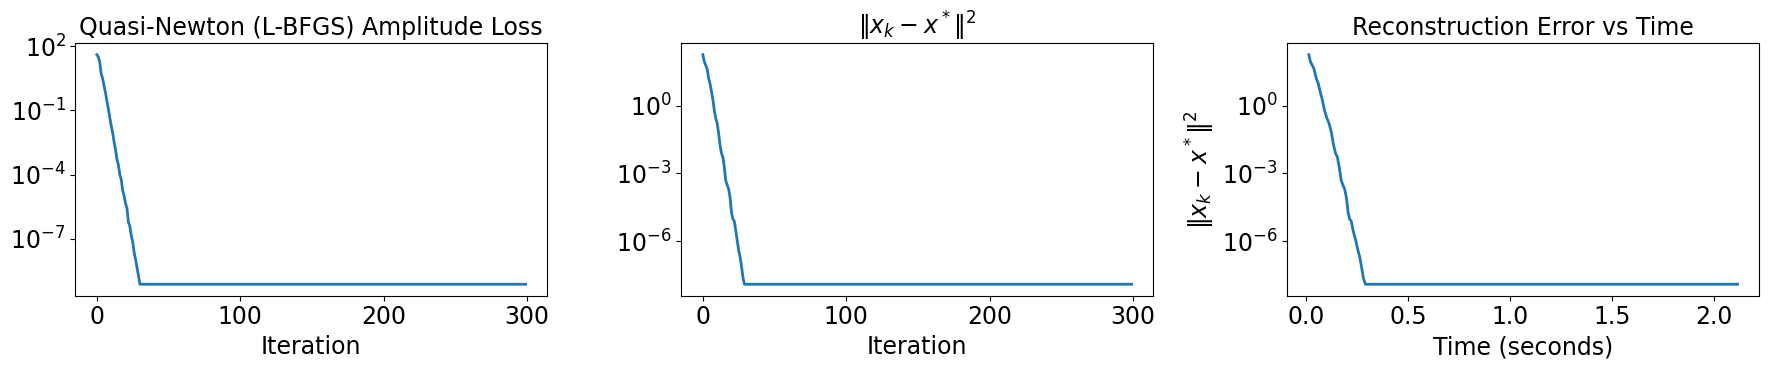

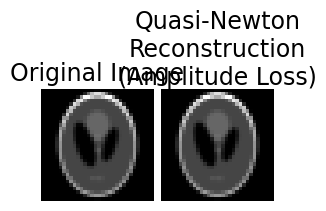

Quasi-Newton Final Loss:         0.000000
Quasi-Newton Final ||x_k-x*||^2: 0.000000


In [20]:
x_phase_qn = physics.A_dagger(y, n_iter=300).clone().detach()
x_phase_qn.requires_grad_(True)

x_true = x_phase.clone().detach()

num_iter = 300
loss_hist = []
recon_error_hist = []
time_hist = []

optimizer = torch.optim.LBFGS(
    [x_phase_qn],
    lr=1.0,
    max_iter=1,
    history_size=10,
    line_search_fn="strong_wolfe"   # None da olabilir
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

for i in range(num_iter):
    iter_start = time.perf_counter()

    def closure():
        optimizer.zero_grad()
        loss = amplitude_loss(x_phase_qn, y, physics)
        loss.backward()
        return loss

    loss = optimizer.step(closure)

    with torch.no_grad():
        x_corrected = correct_global_phase(x_phase_qn.clone(), x_true)
        recon_error = torch.sum(torch.abs(x_corrected - x_true) ** 2).item()
        recon_error_hist.append(recon_error)
        loss_hist.append(loss.item())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    iter_end = time.perf_counter()
    time_hist.append(iter_end - iter_start)

    if i % 20 == 0:
        print(f"[{i}] loss={loss_hist[-1]:.6f}  ||x_k-x*||^2={recon_error_hist[-1]:.6f}")

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()

total_time = end_time - start_time
avg_time = total_time / num_iter

print("initial loss:", loss_hist[0])
print("final loss:", loss_hist[-1])
print(f"Total time: {total_time:.4f} sec")
print(f"Avg per iteration: {avg_time:.6f} sec")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_hist)
axes[0].set_yscale("log")
axes[0].set_title("Quasi-Newton (L-BFGS) Amplitude Loss")
axes[0].set_xlabel("Iteration")

axes[1].plot(recon_error_hist)
axes[1].set_yscale("log")
axes[1].set_title(r"$\|x_k - x^*\|^2$")
axes[1].set_xlabel("Iteration")

cumulative_time = np.cumsum(time_hist)
axes[2].plot(cumulative_time, recon_error_hist)
axes[2].set_yscale("log")
axes[2].set_title("Reconstruction Error vs Time")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel(r"$\|x_k - x^*\|^2$")

plt.tight_layout()
plt.show()

x_qn_corrected = correct_global_phase(x_phase_qn.detach(), x_true)
x_qn_recon = torch.angle(x_qn_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot(
    [x_true_vis, x_qn_recon],
    titles=["Original Image", "Quasi-Newton Reconstruction (Amplitude Loss)"],
    rescale_mode="clip"
)

final_recon_error = torch.sum(torch.abs(x_qn_corrected - x_true) ** 2).item()
print(f"Quasi-Newton Final Loss:         {loss_hist[-1]:.6f}")
print(f"Quasi-Newton Final ||x_k-x*||^2: {final_recon_error:.6f}")

GD semi-log convergence estimate
Fit range         : [4, 30]
slope             : -8.411705e-01
rho = exp(slope)  : 0.431206
C                 : 1.306155e+03
R^2               : 0.998845
ratio mean        : 0.449885
ratio median      : 0.422521
ratio std         : 0.133718
model             : e_k ≈ C * rho^k


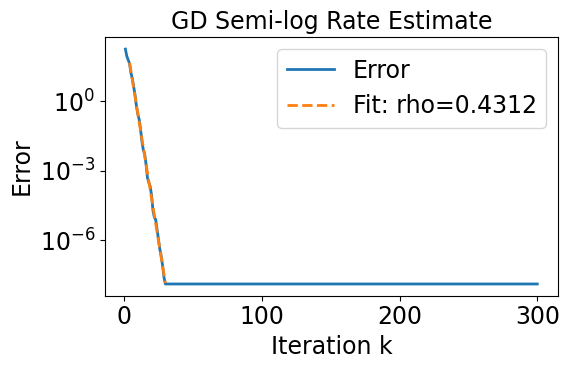

In [22]:
result_qn = {
    "x_final": x_phase_qn.detach(),
    "loss_hist": loss_hist,
    "recon_error_hist": recon_error_hist,
    "time_hist": time_hist,
    "total_time": total_time,
    "avg_time": avg_time,
}

gd_rate = estimate_semilog_rate(
    error_hist=result_qn["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.10,
    method_name="GD",
    plot=True
)